### Section 1 — Identify Outliers  
#### Q1. Read in `outliers.csv`

**Objective.** Load the dataset into a DataFrame and check the structure of the data.

**Steps.**  
1. Import required libraries.  
2. Read the CSV file.  
3. Display the first few rows and summary statistics.


In [33]:
# Q1: Read in outliers.csv
import pandas as pd

df = pd.read_csv("outliers.csv")

df.head()
df.describe()


,x,y
count,101.000000,101.000000
mean,-0.023603,-0.407901
std,0.963081,7.709199
min,-1.948265,-20.108506
25%,-0.737519,-6.386754
50%,0.057059,-1.421664
75%,0.583066,5.233317
max,2.229656,33.700000


### Section 1 — Identify Outliers  
#### Q2. Scatterplot of the data

**Objective.** Visualize the dataset to check for potential outliers.

**Steps.**  
1. Plot `x` on the x-axis and `y` on the y-axis.  
2. Look for points that are far away from the main cluster.


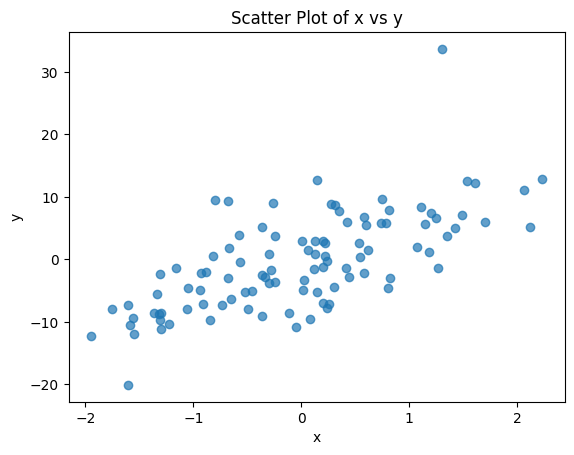

In [34]:
# Q2: Scatterplot of x vs y
import matplotlib.pyplot as plt

plt.scatter(df["x"], df["y"], alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot of x vs y")
plt.show()


### Section 1 — Identify Outliers  
#### Q2. Scatterplot of the data — Interpretation

**Answer.**  
The scatter plot shows a clear potential outlier in the upper-right area of the figure (approximately at x ≈ 1.3, y ≈ 33.7). This point is far from the main cluster of observations and is likely to exert high influence on a fitted regression line.

### Section 1 — Identify Outliers  
#### Q3. Linear regression model

**Objective.** Fit a simple linear regression model predicting `y` from `x`.

**Steps.**  
1. Define `y` as the dependent variable and `x` as the independent variable.  
2. Add a constant for the intercept.  
3. Fit the model using OLS from statsmodels.  
4. Print the summary.


In [35]:
# Q3: Linear regression y ~ x
import statsmodels.api as sm

X = sm.add_constant(df["x"])  # add intercept
y = df["y"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     83.49
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           8.34e-15
Time:                        20:32:56   Log-Likelihood:                -318.21
No. Observations:                 101   AIC:                             640.4
Df Residuals:                      99   BIC:                             645.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2801      0.568     -0.493      0.6

### Section 1 — Identify Outliers  
#### Q4. Cook’s distance plot

**Objective.** Use Cook’s distance to identify influential points that may be outliers.

**Steps.**  
1. Calculate Cook’s distance from the fitted regression model.  
2. Plot the values for each observation.  
3. Look for points with unusually high Cook’s distance.


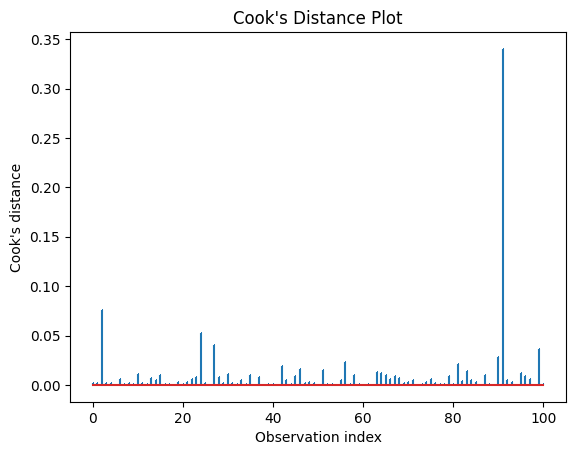

(np.int64(91), np.float64(0.3401165748041629))

In [36]:
# Q4: Cook's distance plot (fixed for new matplotlib)
import numpy as np
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance Plot")
plt.show()

# Find the index of the maximum Cook's distance
max_cooks = np.argmax(cooks_d)
max_cooks, cooks_d[max_cooks]


### Section 1 — Identify Outliers  
#### Q5. Re-run regression without the worst outlier

**Objective.** Remove the most influential outlier (highest Cook’s distance) and re-fit the regression model.

**Steps.**  
1. Identify the observation with the maximum Cook’s distance.  
2. Remove it from the dataset.  
3. Fit the regression model again.  
4. Compare the results to the original model.


### Section 1 — Identify Outliers  
#### Q5. Re-run regression without the worst outlier — Comparison

**Answer.**  
After removing the observation with the highest Cook’s distance and re-fitting the model:

- **Goodness of fit improved:** R² increased (the model explains more variance).  
- **Coefficient stability improved:** The slope decreased from about 5.41 to about 5.02, indicating the outlier had been inflating the estimated effect of `x` on `y`.  
- **Residuals are more well-behaved:** Normality diagnostics (e.g., Omnibus and Jarque–Bera) improved, suggesting the refit model meets OLS assumptions better.

**Conclusion.** Removing the most influential outlier leads to a more reliable model with better fit and diagnostics.

In [37]:
# Q5: Remove worst outlier and re-run regression
max_cooks = np.argmax(cooks_d)
df_rm_out = df.iloc[df.index != max_cooks]

X_new = sm.add_constant(df_rm_out["x"])
y_new = df_rm_out["y"]

model_new = sm.OLS(y_new, X_new).fit()
print(model_new.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     90.66
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           1.32e-15
Time:                        20:32:56   Log-Likelihood:                -302.37
No. Observations:                 100   AIC:                             608.7
Df Residuals:                      98   BIC:                             614.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5641      0.503     -1.121      0.2

### Section 2 — Multiple Regression  
#### Q1. Load dataset from mpg.db with SQL query

**Objective.** Connect to the `mpg.db` database and load the dataset using the specified SQL query.

**Steps.**  
1. Use `sqlite3` to connect to the database.  
2. Run the SQL query joining `observation`, `name`, and `origin`.  
3. Create a DataFrame and show the first few rows plus summary statis


In [38]:
# Q1: Load dataset from mpg.db with SQL query
import sqlite3

conn = sqlite3.connect("mpg.db")

query = """
SELECT n.name, org.origin, o.mpg, o.cylinders, o.displacement, 
       o.horsepower, o.weight, o.acceleration, o.model_year
FROM observation o
JOIN name n ON o.name_id = n.name_id
JOIN origin org ON o.origin_id = org.origin_id
WHERE o.horsepower IS NOT NULL
"""

df_mpg = pd.read_sql(query, conn)

# Show preview and summary stats
df_mpg.head()
df_mpg.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


### Section 2 — Multiple Regression  
#### Q2. Create dummy variables for origin

**Objective.** Convert the categorical `origin` column into dummy variables so it can be included in regression.

**Steps.**  
1. Use `pd.get_dummies()` to create dummy variables.  
2. Drop the first category to avoid multicollinearity (dummy variable trap).  
3. Convert dummy variables to integers.


In [39]:
# Q2: Create dummy variables for origin
df_dummies = pd.get_dummies(df_mpg["origin"], prefix="origin", drop_first=True).astype(int)

# Add dummy columns to the dataframe
df_mpg_dum = pd.concat([df_mpg, df_dummies], axis=1)

df_mpg_dum.head()


,name,origin,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,chevrolet chevelle malibu,usa,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,buick skylark 320,usa,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,plymouth satellite,usa,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,amc rebel sst,usa,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,ford torino,usa,17.0,8,302.0,140.0,3449,10.5,70,0,1


### Section 2 — Multiple Regression  
#### Q3. Check for collinearity

**Objective.** Examine correlations among numeric predictors to identify potential multicollinearity issues.

**Steps.**  
1. Select only numeric columns.  
2. Calculate the correlation matrix.  
3. Inspect for very high correlations (above ~0.8).


In [40]:
# Q3: Check collinearity
numeric_df = df_mpg_dum.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

corr_matrix


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.451454,-0.565161
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.404209,0.610494
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.440825,0.655936
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.321936,0.489625
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.447929,0.600978
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.115020,-0.258224
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.199841,-0.136065
origin_japan,0.451454,-0.404209,-0.440825,-0.321936,-0.447929,0.115020,0.199841,1.000000,-0.648583
origin_usa,-0.565161,0.610494,0.655936,0.489625,0.600978,-0.258224,-0.136065,-0.648583,1.000000


### Section 2 — Multiple Regression  
#### Q3. Preliminary check for collinearity — Interpretation

**Answer.**  
The correlation matrix indicates **very high correlations** among several numeric predictors, notably:

- `displacement`, `horsepower`, `weight`, and `cylinders` (pairwise correlations frequently > 0.85–0.95).  
- These strong correlations signal **multicollinearity**, which can inflate standard errors and make individual coefficients unstable and hard to interpret.

**Implication.** Multicollinearity does not harm overall prediction necessarily, but it undermines inference about individual effects. We will confirm this later with VIF.

### Section 2 — Multiple Regression  
#### Q4. Multiple regression with all numeric variables and dummies

**Objective.** Build a regression model to predict `mpg` using all numeric predictors and origin dummies.

**Steps.**  
1. Select all numeric predictors (`cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin_japan`, `origin_usa`).  
2. Add a constant term.  
3. Fit the regression model with `mpg` as the dependent variable.  
4. Display the summary.


In [41]:
# Q4: Multiple regression model
import statsmodels.api as sm

X = df_mpg_dum[["cylinders", "displacement", "horsepower", "weight", 
                "acceleration", "model_year", "origin_japan", "origin_usa"]]
y = df_mpg_dum["mpg"]

X = sm.add_constant(X)
model_full = sm.OLS(y, X).fit()
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Wed, 01 Oct 2025   Prob (F-statistic):          1.79e-139
Time:                        20:32:56   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -15.3246      4.602     -3.330   

### Section 2 — Multiple Regression  
#### Q5. Regression with log2(horsepower)

**Objective.** Transform `horsepower` with `log2` to reduce skewness and check its effect on mpg.

**Steps.**  
1. Create a new column `log_horsepower = np.log2(horsepower)`.  
2. Replace `horsepower` with this new variable in the regression model.  
3. Fit the model and compare results to the previous one.


In [42]:
# Q5: Regression with log2(horsepower)
import numpy as np

df_mpg_dum["log_horsepower"] = np.log2(df_mpg_dum["horsepower"])

X_log = df_mpg_dum[["cylinders", "displacement", "log_horsepower", "weight",
                    "acceleration", "model_year", "origin_japan", "origin_usa"]]
y_log = df_mpg_dum["mpg"]

X_log = sm.add_constant(X_log)
model_log = sm.OLS(y_log, X_log).fit()
print(model_log.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     248.8
Date:                Wed, 01 Oct 2025   Prob (F-statistic):          1.46e-146
Time:                        20:32:56   Log-Likelihood:                -1003.7
No. Observations:                 392   AIC:                             2025.
Df Residuals:                     383   BIC:                             2061.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             28.0416      8.624      3.

### Section 2 — Multiple Regression  
#### Q5. Regression with `log2(horsepower)` — Coefficient interpretation

**Answer.**  
Using `log2(horsepower)` means a **one-unit increase** in this predictor corresponds to **doubling horsepower**. Therefore, the coefficient on `log2(horsepower)` represents the expected change in `mpg` for a **doubling of horsepower**, holding the other variables constant.

In our results, the coefficient is approximately **−6.41**, which implies that **doubling horsepower is associated with about a 6.4 mpg decrease**, ceteris paribus.

### Section 2 — Multiple Regression  
#### Q6. Variance Inflation Factor (VIF)

**Objective.** Evaluate multicollinearity among predictors using VIF.

**Steps.**  
1. Select all predictors from the log-horsepower model.  
2. Use `variance_inflation_factor` from `statsmodels`.  
3. Report VIF values and discuss concerns.


In [43]:
# Q6: Calculate VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_log.drop(columns=["const"])  # exclude intercept
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data


,Variable,VIF
0,cylinders,118.824731
1,displacement,93.572646
2,log_horsepower,399.986669
3,weight,132.506996
4,acceleration,54.184526
5,model_year,361.693381
6,origin_japan,2.295484
7,origin_usa,6.969860


### Section 2 — Multiple Regression  
#### Q6. Interpretation of VIF results

**Answer.**  
The VIF values reveal severe multicollinearity among several predictors:

- `log_horsepower`, `model_year`, `weight`, `cylinders`, `displacement`, and `acceleration` all have extremely high VIF values (well above 10).  
- Only the dummy variables for `origin` have acceptable VIF values (< 10).  

**Implications.**  
These results confirm that the numeric predictors are highly correlated, meaning their coefficients are unstable and difficult to interpret individually.  

**Possible solutions.**  
- Drop one or more highly correlated variables (e.g., keep `weight` and `model_year` while removing `displacement` or `cylinders`).  
- Use dimensionality reduction (such as PCA) to combine correlated predictors.  
- Focus interpretation on variables with lower collinearity or on the overall predictive power of
